In [3]:
from google.colab import files
datafile = files.upload()

Saving bank-additional-full.csv to bank-additional-full.csv


In [4]:
import pandas as pd
data = pd.read_csv('/content/bank-additional-full.csv', sep=';')
data.head()
data.shape

(41188, 21)

In [5]:
new_data = data.sample(n=5000, random_state=42).reset_index(drop=True)
new_data.head()
new_data.shape
new_data.to_csv('bank_additional_data.csv', index=False)
new_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,57,technician,married,high.school,no,no,yes,cellular,may,mon,...,1,999,1,failure,-1.8,92.893,-46.2,1.299,5099.1,no
1,55,unknown,married,unknown,unknown,yes,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
2,33,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,1,999,1,failure,-1.8,92.893,-46.2,1.313,5099.1,no
3,36,admin.,married,high.school,no,no,no,telephone,jun,fri,...,4,999,0,nonexistent,1.4,94.465,-41.8,4.967,5228.1,no
4,27,housemaid,married,high.school,no,yes,no,cellular,jul,fri,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no


In [6]:
# new_data.info()
# new_data.isnull().sum()
# new_data.describe()
import numpy as np
(new_data == 'unknown').sum()
new_data = new_data.replace('unknown', np.nan)
new_data.isnull().sum()

,0
age,0
job,38
marital,8
education,190
default,1052
housing,113
loan,113
contact,0
month,0
day_of_week,0


In [7]:
for col in ['job', 'marital', 'education', 'housing','loan']:
  most_frequent = new_data[col].mode()[0]
  new_data[col] = new_data[col].fillna(most_frequent)


In [8]:
new_data['default'] = new_data['default'].fillna('unknown')
new_data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


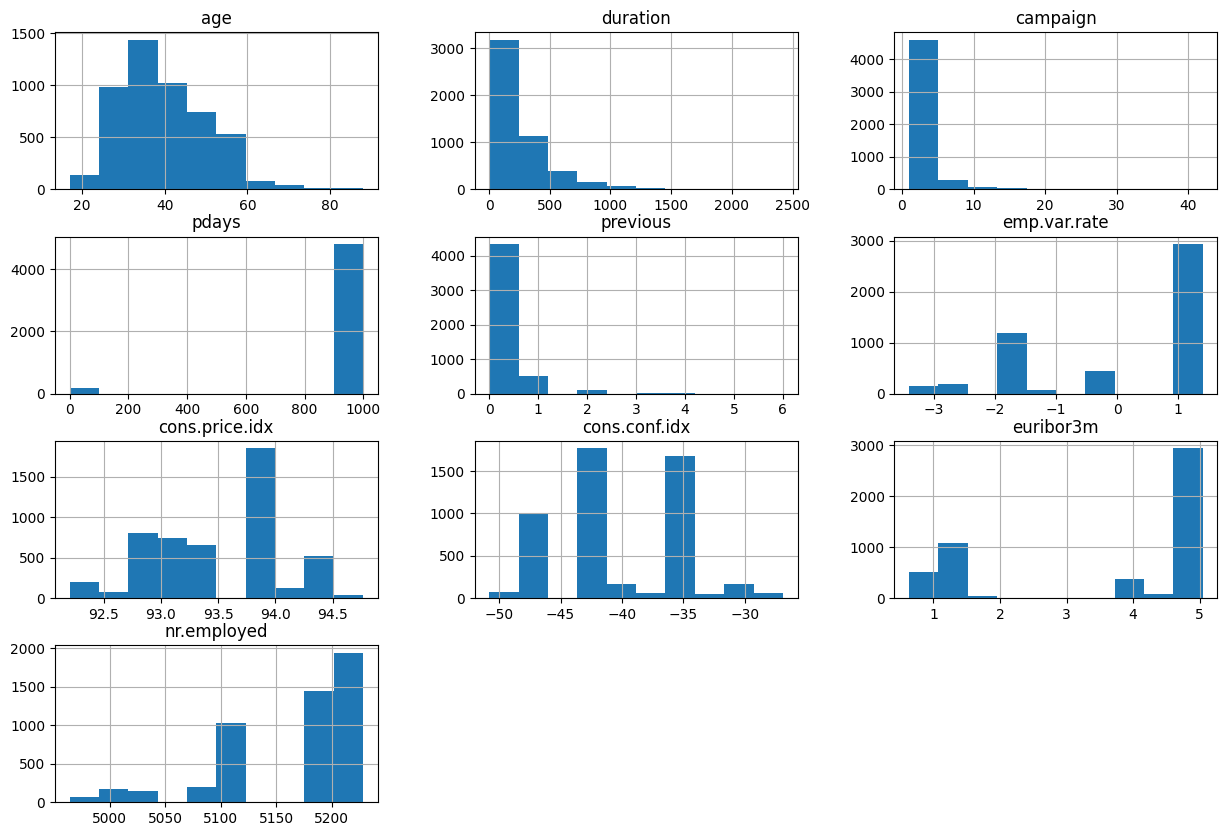

In [9]:
import matplotlib.pyplot as plt

new_data.hist(figsize=(15,10))
plt.show()

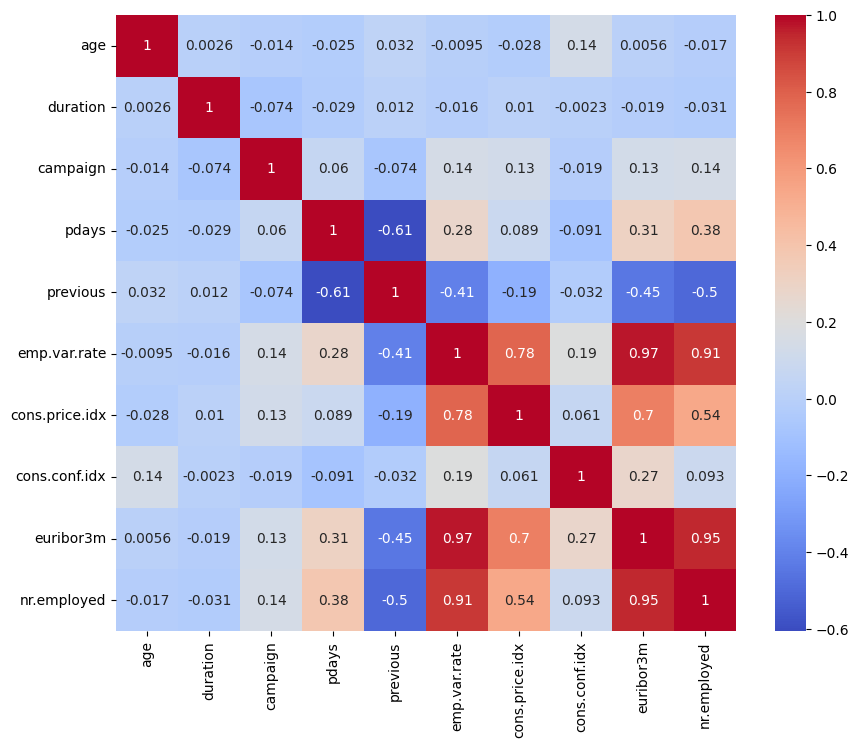

In [10]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(new_data.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm'
)
plt.show()

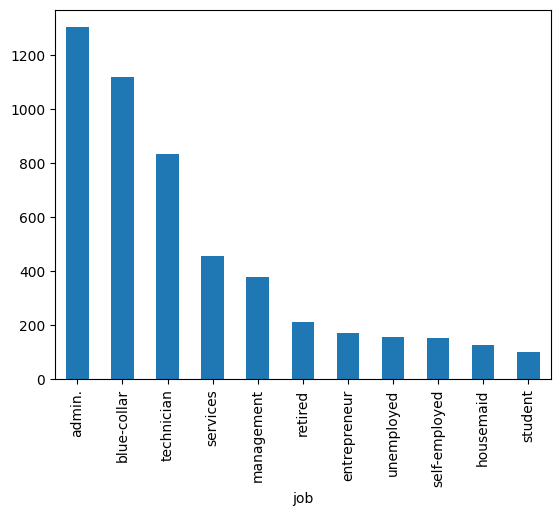

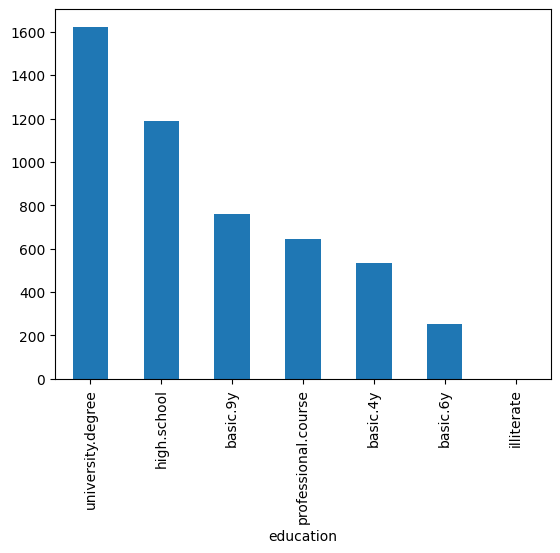

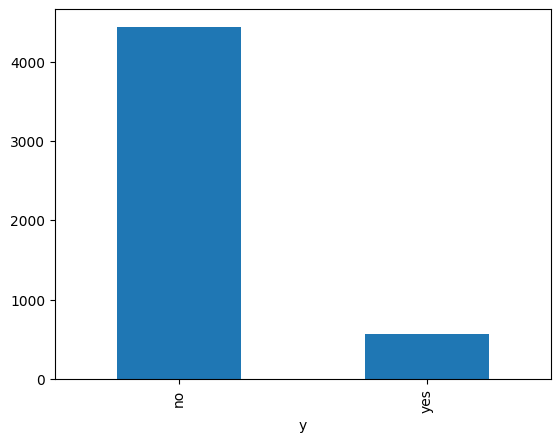

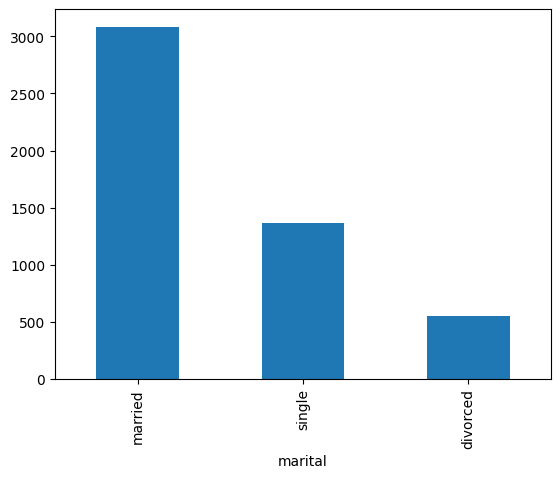

In [11]:
new_data['job'].value_counts().plot(kind='bar')
plt.show()
new_data['education'].value_counts().plot(kind='bar')
plt.show()
new_data['y'].value_counts().plot(kind='bar')
plt.show()
new_data['marital'].value_counts().plot(kind='bar')
plt.show()


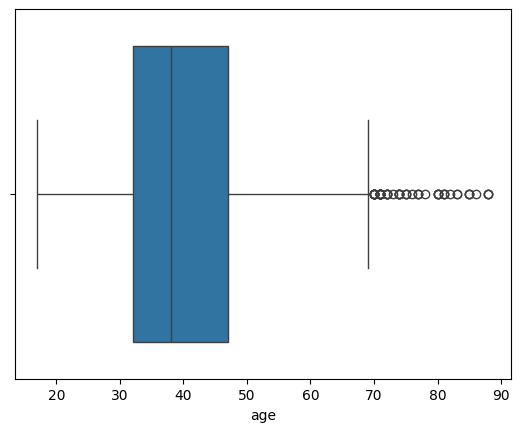

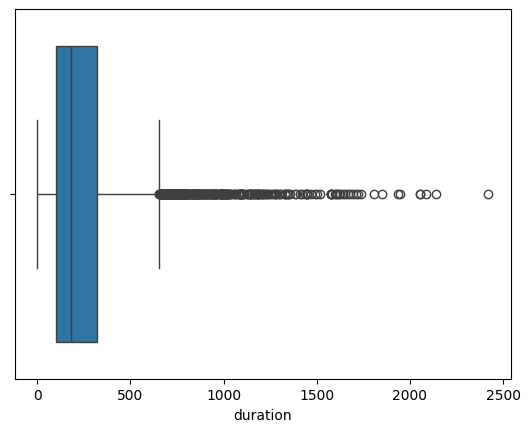

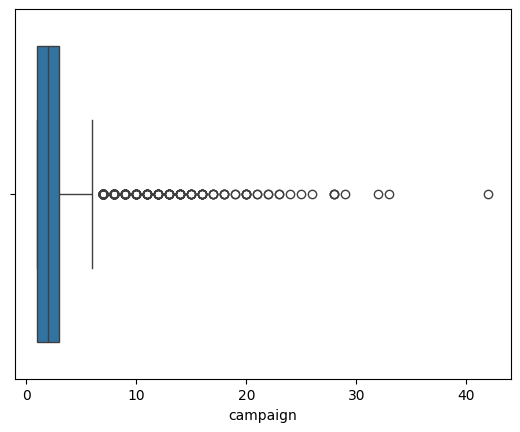

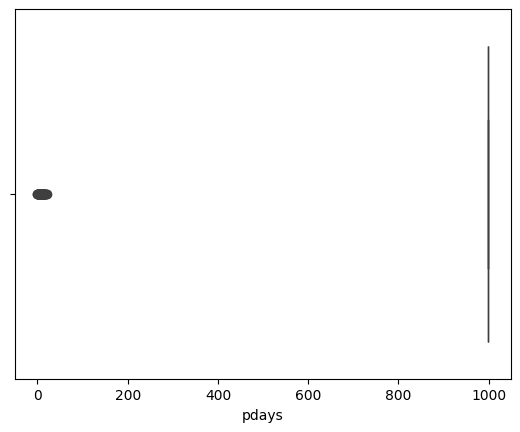

In [12]:
import seaborn as sns

sns.boxplot(x=new_data['age'])
plt.show()
sns.boxplot(x=new_data['duration'])
plt.show()
sns.boxplot(x=new_data['campaign'])
plt.show()
sns.boxplot(x=new_data['pdays'])
plt.show()

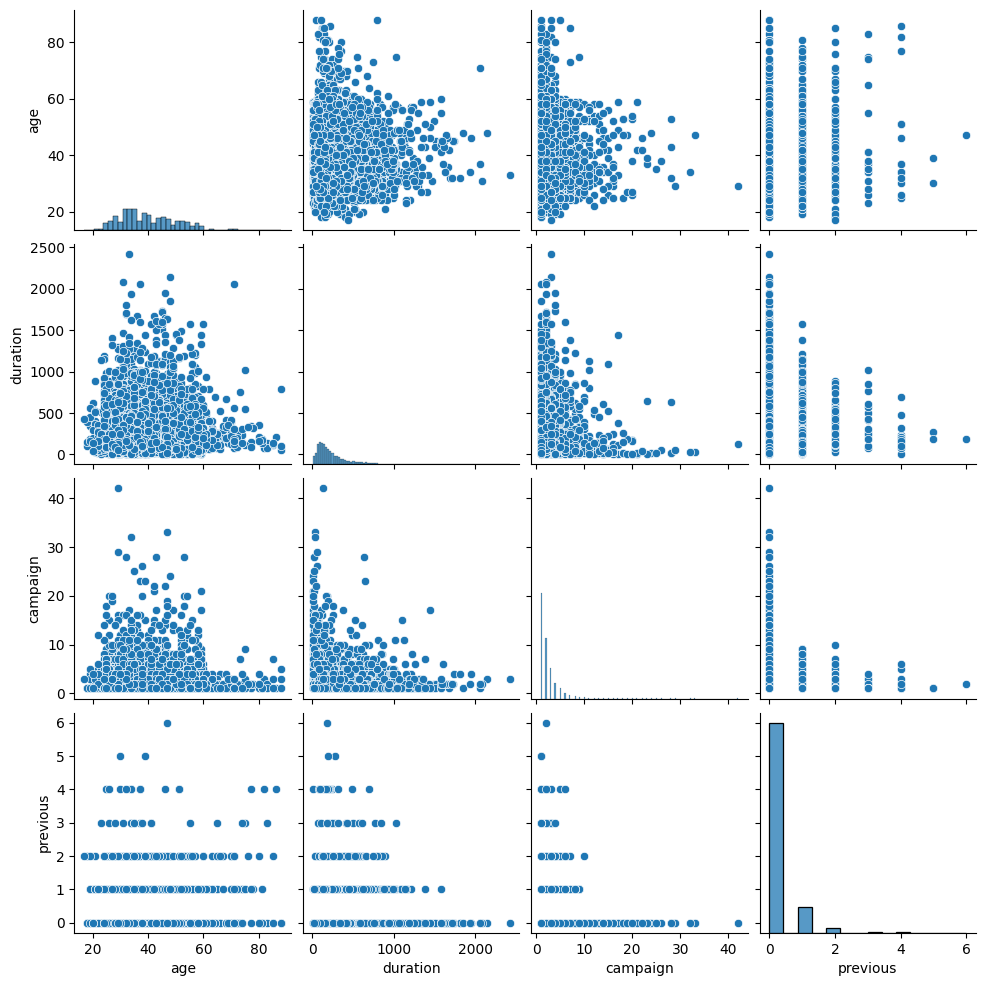

In [13]:
sns.pairplot(
    new_data[['age','duration','campaign','previous']]
)

In [14]:
new_data['job'].unique()
new_data['education'].unique()
# new_data['month'].unique()
# new_data['day_of_week'].unique()
# new_data['poutcome'].unique()


array(['high.school', 'university.degree', 'basic.9y',
       'professional.course', 'basic.4y', 'basic.6y', 'illiterate'],
      dtype=object)

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(new_data.drop('y',axis=1),new_data['y'],test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((4000, 20), (1000, 20), (4000,), (1000,))

In [16]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['education', 'month', 'day_of_week', 'poutcome']

oe = OrdinalEncoder()

X_train[cat_cols] = oe.fit_transform(X_train[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])
X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
4227,35,admin.,married,3.0,no,yes,no,cellular,6.0,2.0,170,1,999,0,1.0,-1.8,92.893,-46.2,1.266,5099.1
4676,49,admin.,married,6.0,no,yes,no,cellular,6.0,0.0,168,1,999,0,1.0,-1.8,92.893,-46.2,1.259,5099.1
800,51,blue-collar,married,2.0,no,yes,no,telephone,6.0,1.0,812,1,999,0,1.0,1.1,93.994,-36.4,4.857,5191.0
3671,42,housemaid,single,0.0,unknown,yes,no,telephone,6.0,3.0,198,1,999,0,1.0,1.1,93.994,-36.4,4.857,5191.0
4193,41,blue-collar,married,1.0,unknown,yes,no,telephone,4.0,4.0,950,4,999,0,1.0,1.4,94.465,-41.8,4.959,5228.1


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
pd.DataFrame(y_train)

,0
0,0
1,0
2,0
3,0
4,0
...,...
3995,0
3996,0
3997,0
3998,0


In [18]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

cat_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact']

X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

encoded_df.head()
X_train_final = X_train.drop(columns=cat_cols)
X_train_final = pd.concat(
    [X_train_final, encoded_df],
    axis=1
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)
X_test_final = X_test.drop(columns=cat_cols)
X_test_final = pd.concat(
    [X_test_final, X_test_encoded_df],
    axis=1
)
X_train_final.head()

,age,education,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,...,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_unknown,housing_yes,loan_yes,contact_telephone
4227,35,3.0,6.0,2.0,170,1,999,0,1.0,-1.8,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4676,49,6.0,6.0,0.0,168,1,999,0,1.0,-1.8,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
800,51,2.0,6.0,1.0,812,1,999,0,1.0,1.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3671,42,0.0,6.0,3.0,198,1,999,0,1.0,1.1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
4193,41,1.0,4.0,4.0,950,4,999,0,1.0,1.4,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0


In [19]:
import pandas as pd

train_dataset = X_train_final.copy()

train_dataset['y'] = pd.Series(y_train, index=X_train_final.index)

test_dataset = X_test_final.copy()

test_dataset['y'] = pd.Series(y_test, index=X_test_final.index)

test_dataset.shape

(1000, 31)

In [20]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train_final,y_train)

RandomForestClassifier(random_state=42)

In [21]:
model.score(X_test_final,y_test)

0.909

In [22]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_final)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       883
           1       0.68      0.43      0.52       117

    accuracy                           0.91      1000
   macro avg       0.80      0.70      0.74      1000
weighted avg       0.90      0.91      0.90      1000



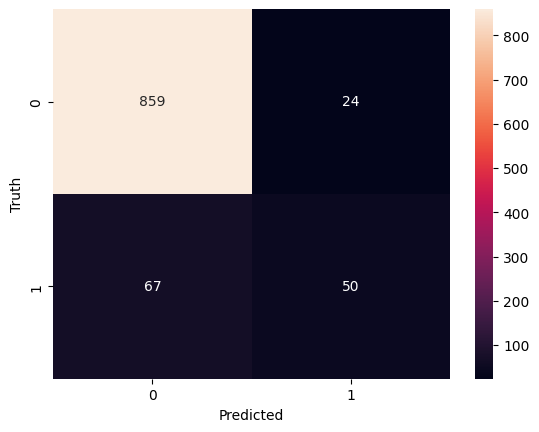

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [24]:
import pickle

saved={
    'model':model,
    'ordinal_encoder':oe,
    'label_encoder':le,
    'one_hot_encoder':ohe,
}

with open('bank_marketing_data.pkl','wb') as f:
  pickle.dump(saved,f)

In [25]:
with open('bank_marketing_data.pkl','rb') as f:
  saved=pickle.load(f)
model=saved['model']
oe=saved['ordinal_encoder']
le=saved['label_encoder']
ohe=saved['one_hot_encoder']
